# Project 4 -- Niharika Rai

**TA Help:** (for instance) John Smith, Alice Jones, etc., list names of any TAs who helped you

- For example: Help with figuring out how to write a function (describe the tasks that they helped you with)

**Collaboration:** My Friend in CS, My Uncle, Another Student, etc., list names of any other people who helped you

(describe the tasks that they helped you with)
- For example: helped figuring out how to load the dataset.
- Another example: helped debug error with my plot.

**Internet Resources:** Stack Exchange, Stack Overflow, etc.

(describe any information that you learned from internet resources, including the URLs)
- data frames in Pandas versus R from StackOverflow  https://stackoverflow.com/questions/8991709/why-were-pandas-merges-in-python-faster-than-data-table-merges-in-r-in-2012

**ChatGPT, Gemini, Claude, etc:** Any language models or generative AI chatbots that helped you.

(if you used any such tools, please tell us here)
- For example:  I asked ChatGPT how to define a new data frames
- Another example:  Gemini told me how to make a function for sorting my data

- ***Link to AI Chat History***: Please share a link to your chat if you used AI (ex. ChatGPT Shared Links)
**OVERALL MESSAGE:** Any time that you used anything except your brain to solve the questions in these projects, you need to disclose such resources at the start of the project, with details about your usage of the tools. Here is the link to AI Chat History: https://chatgpt.com/share/699538db-1d40-800d-a9a1-afe9fa07060d https://chatgpt.com/share/699538fb-8280-800d-bf9f-9fa503123099 

**YOUR OWN WORK:** Even when you utilize other resources, do NOT just copy and paste.  Write all explanations in your own words, using several sentences in English, which are understandable and which you wrote (and did not just copy and paste).

## Question 1

In [1]:
import pandas as pd
df = pd.read_csv("/anvil/projects/tdm/data/olympics/athlete_events.csv")
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [2]:
print(df.head())

   ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0           China   
1   2                  A Lamusi   M  23.0   170.0    60.0           China   
2   3       Gunnar Nielsen Aaby   M  24.0     NaN     NaN         Denmark   
3   4      Edgar Lindenau Aabye   M  34.0     NaN     NaN  Denmark/Sweden   
4   5  Christine Jacoba Aaftink   F  21.0   185.0    82.0     Netherlands   

   NOC        Games  Year  Season       City          Sport  \
0  CHN  1992 Summer  1992  Summer  Barcelona     Basketball   
1  CHN  2012 Summer  2012  Summer     London           Judo   
2  DEN  1920 Summer  1920  Summer  Antwerpen       Football   
3  DEN  1900 Summer  1900  Summer      Paris     Tug-Of-War   
4  NED  1988 Winter  1988  Winter    Calgary  Speed Skating   

                              Event Medal  
0       Basketball Men's Basketball   NaN  
1      Judo Men's Extra-Lightweight   NaN  
2           Football Men's

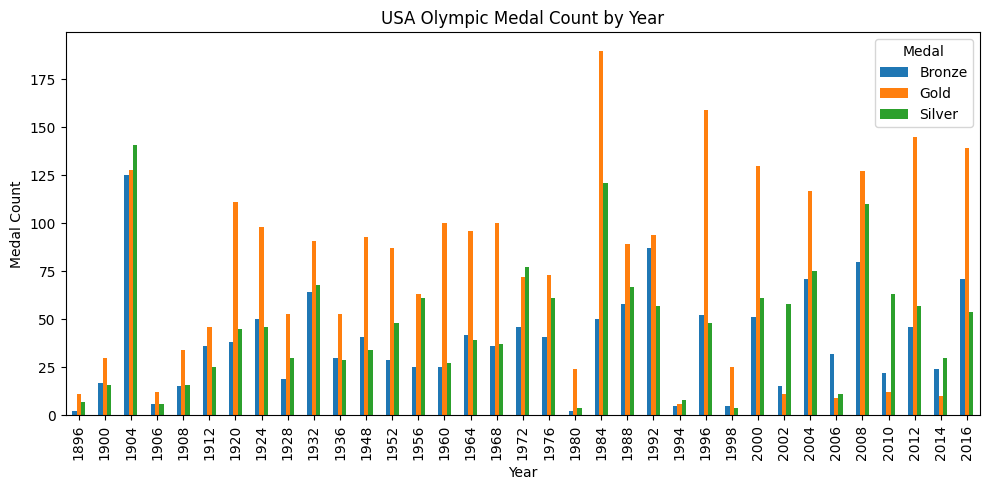

In [3]:
import matplotlib.pyplot as plt 

usa = df[(df["NOC"] == "USA") & (df["Medal"].isin(["Gold", "Silver", "Bronze"]))]
medals = usa.groupby(["Year", "Medal"]).size().unstack()

medals.plot(kind="bar", figsize=(10, 5))

plt.xlabel("Year")
plt.ylabel("Medal Count")
plt.title("USA Olympic Medal Count by Year")
plt.legend(title="Medal")
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import ipywidgets as widgets
from ipywidgets import Dropdown, Button, Output, VBox

from IPython.display import display

import plotly.express as px
import plotly.io as pio

pio.renderers.default = "notebook"

# Create a dataset containing athletes with medals
medals = df[df['Medal'].notna()]

# Group data by country, year, medal type
medal_noc = medals.groupby(['NOC', 'Year', 'Medal']).size().reset_index(name='Count')

In [5]:
medal_noc

,NOC,Year,Medal,Count
0,AFG,2008,Bronze,1
1,AFG,2012,Bronze,1
2,AHO,1988,Silver,1
3,ALG,1984,Bronze,2
4,ALG,1992,Bronze,1
...,...,...,...,...
3234,ZIM,2004,Bronze,1
3235,ZIM,2004,Gold,1
3236,ZIM,2004,Silver,1
3237,ZIM,2008,Gold,1


In [44]:
import pandas as pd
import ipywidgets as widgets
from ipywidgets import Dropdown, Button, Output, VBox

from IPython.display import display

import plotly.express as px
import plotly.io as pio

# Selecting countries listed in alphabetical order
dropdown = Dropdown(options=sorted(df['NOC'].unique()), description='Country (NOC):')
# Output for plot
output = widgets.Output()

# Update medal plot based on country selection
def medal_plot(change):
    # Clear previous output
    output.clear_output()
    # Put all outputs into the output widget
    with output:
        noc = change["new"] 
        
        country_df = medals[medals['NOC'] == noc]
        
        new_df = (
        country_df
        .groupby(['Year', 'Medal'])
        .size()
        .reset_index(name='Count')
    )
        if new_df.empty:
          # Print message for the user
            print("There is no medal data for the selected country.")
        else:
            # Create plotly bar char with all labels (year, count, country) and title
            fig = px.bar(new_df, x='Year', y='Count', color='Medal', title=f'Medal Counts by Year - {noc}', barmode='stack')
            fig.show()

dropdown.observe(medal_plot, names='value')
medals_panel = widgets.VBox([widgets.Label("Medal Counts for Countries"), dropdown, output])
display(medals_panel)

1a. I used the head function to display the first few rows in the dataset. The initial obervations are that each athlete is identified by their unique ID. The different columns are name, age, height, weight, sex, team, NOC, games, year, season, city, sport, event, and medal. These columns convey the sport and Olympic-related information about each player. I used the sample code from the question to plot this stacked bar plot. It shows the Olympic Medal Counts by Year for USA.  

1b. I used the sample code in the question to create a dataframe only containing athletes who have won medals (removed rows with no medal), and group data by country, year, medal type. 

1c. I used the sample code in the question to create an interactive widget and medal plot for country selection. The countries are listed in alphabetical order. I used ChatGPT to debug my code because my initial code plotted the stacked bar plot but it had gaps in them, which did not occur in the sample output image in the question. I realized that these gaps occured because I had not filtered the dataframe by country first and had not grouped it by Year and Medal.   

1d. In context of our example, Dropdown allows users to select which country’s medal data they want to view. It has 3 attributes: options (allows us to specify the country choices and view them in alphabetical order), value (the currently selected option from the dropdown is stored here so it lets us filter the dataset and update the plot) and description (lets us add labels). Viewbox holds the label, dropdown, and output together. So, when the plot is displayed, the label appears at the top like a title, the dropdown appears below with selection options, and the output widget provides an area for displaying plots to the user. Hence, the Vbox helps to display the visual plots, based on the country selected in the Dropdown menu.   

1e. In my opinion, the difference between the interactive Plotly + widget visualization and the traditional, static plotting methods are that the interactive Plotly + widget visualizations are interactive. They allow us to change the visualization using features such as buttons, sliders, progress bars, checkbox, and texts. Our plots look much better and active with Plotly and widget visualizations. However, the traditional, static plotting methods cannot be changes, unless we change the code and re-run the code cell. It is as good as an image that conveys information but we cannot implement any interactive feautures that allow us to view numbers, trends etc. I believe that interactive Plotly + widget visualizations would be preferred when building complex visualizations because they have interactive features that help to simply the plot's complexity and allows the user to understand intricate trends that are not so obvious. Then, the static plots would be preferred when showing simpler graphs, that can also be used as images for a poster and do not require user interactivity to understand any intricate patterns because every detail in the plot is obvious to the user. To sum up, the advantages of an interactive Plotly + widget visualization are that it encourages user exploration and engagement and provides a cleaner user interface for multi-dimensional data. Its disadvantages are that it requires more complicated code to build, and it is not preferred for prints or reports. The advantages of static traditional plots are that they are simpler and faster to create and are better suited for publication and documentation. Its disdadvantages are that it has no interactivity and it is less efficient for large and complex data.   

## Question 2

In [46]:
# Create dropdown widget to select which physical traits data we want to view
# The 'options' are age, height, and weight. You should also include 'description'
dropdown2 = widgets.Dropdown(options=['Age', 'Height', 'Weight'], description='Physical Trait:')

# Create a slider widget allowing user to select the range of years
slider = widgets.IntRangeSlider(value=[ df['Year'].min(),  df['Year'].max()],
                                min = df['Year'].min(),
                                max= df['Year'].max(),
                                description='Year Range:')

# Create an output widget displaying histogram/messages
traits_output = widgets.Output()

def trait_histogram(change):
    # Clear previous output
    traits_output.clear_output()
    # Read selected trait from dropdown. Determines which column of dataset we will output.
    attr = dropdown2.value
    # Extracts selected year range from slider. This returns (min year, max year)
    yr_min, yr_max = slider.value

    # Filter the dataset to include athletes 1) within selected year range 2) with non missing values for selected trait
    filtered_df = df[
        (df['Year'] >= yr_min) &
        (df['Year'] <= yr_max) &
        (df[attr].notna())
    ]

    with traits_output:
        # Message for the user if the filtered dataset is empty
        if filtered_df.empty:
            print("There is no data for the selected filters.")
        # Create a histogram using px.histogram()
        else:
            fig = px.histogram(
                filtered_df,
                x=attr,
                title=f"{attr} Distribution ({yr_min}-{yr_max})",
                labels={
                    attr: attr,
                    "count": "Number of Athletes"
                }
            )
            
            fig.update_layout(
                xaxis_title=attr,
                yaxis_title="Number of Athletes"
            )
            
            fig.show()

# .observe() for dropdwon
dropdown2.observe(trait_histogram, names='value')

# .observe() for slider
slider.observe(trait_histogram, names='value')


# Create traits panel
traits_panel = widgets.VBox([dropdown2, slider, traits_output])
# Display
display(traits_panel)

2a. I wrote the code for creating dropdown widget to select traits and year range slider that allow users to limit analysis to specific Olympic years. I used the sample code but since it was incomplete, I tried to fill in the code blanks. When I ran my code, it broke in-between and so I used ChatGPT to debug my code and fix the errors. 

2b. I wrote the code for the function trait_histogram. There were some syntax errors and improper variable referencing which is why my code was breaking, so I used ChatGPT to debug my code.  

2c. The trait_histogram function works by referencing the dropdown where the physical traits were listed and the slider where the year ranges were specified. In the function, we filter the dataset by only keeping the columns of the traits specified within the given year ranges and ensuring that none of the columns have null values. We use this filtered dataframe to construct the histogram with specified labels and a title. The visual itself would only reference and plot that part of the filtered df that has been specified in the dropdown menu and slider.   

2d. In the output above, I selected Height as the physical trait and set the year range from 1983 to 2016. The histogram auto-updates based on the slider to show the height distribution of Olympic Athletes from 1983 to 2016. The histogram is also labelled where the title is, "Height Distribution (1983-2016)", x-axis represents the various heights and the y-axis represents the number of athletes. 

## Question 3

In [47]:
# Get unique sports from the dataset and sort them alphabetically
sports = sorted(df['Sport'].unique())
# Widget to choose sports
sports_select = widgets.SelectMultiple(options=sports, description='Sports:')
# Create dropdwon widget to select Olympic season
# Available options are summer and winter, and set default to summer. Also add the description
season_dropdown = widgets.Dropdown(
    options=['Summer', 'Winter'],
    value='Summer',
    description='Season:')

# Create output widget to show the plot/messages
sport_output = widgets.Output() 

def sports_plot(change):
    # Clear previous output
    sport_output.clear_output()
    # Read selected sport from dropdown. Determines which column of dataset we will output.
    selected_sports = list(sports_select.value)
    selected_season = season_dropdown.value

    # Filter the dataset
    filtered_df = df[
        (df['Season'] == selected_season) &
        (df['Sport'].isin(selected_sports))
    ]
    
    with sport_output:
        # Message for the user if the filtered dataset is empty
        if filtered_df.empty:
            print("There is no data for the selected filters.")
        else:
            # Count participants per year
            trend_df = (
                filtered_df
                .groupby('Year')
                .size()
                .reset_index(name='Participants')
            )
            
            # Create line plot
            fig = px.line(
                trend_df,
                x='Year',
                y='Participants',
                title=f"Participation Over Time - {selected_season}",
                labels={
                    'Year': 'Year',
                    'Participants': 'Participants'
                }
            )
            
            fig.show()

# .observe() for dropdwon
sports_select.observe(sports_plot, names='value')

# .observe() for slider
season_dropdown.observe(sports_plot, names='value')

# Create sports panel
sports_panel = widgets.VBox([sports_select, season_dropdown, sport_output])

# Display
display(sports_panel)

3a. I completed the code for creating widgets. I was initially getting errors so I used ChatGPT to debug my code. I realized that I had not referenced the values properly, resulting in syntax errors. 

3b. I wrote the code for sports_plot() function and added comments. I was getting errors as I had not filtered and calculated the participants per year so my code was incomplete. I used ChatGPT to debug my code and understand the logic behind calculating the participants per year, which was then used to create the line plot. The line plot output above matches the sample output shown in the question. But the only difference is that my y-axis goes till 400 and the image in the question shows its output only till 200. However, the trend remains the same.   

3c. The line plot above shows the trend for participation over time during summer, specifically for the equestrianism sport. While there are sharp dips in 1932 and 1980, the overall trend shows an upward positive correlation with time. This means that as time increased/passed, the participation for this sport generally has increased. For example, the largest increase was in the summer of 1992 with a total participation of 404 people. 

## Question 4

In [66]:
import ipywidgets as widgets
from IPython.display import display
import plotly.express as px

# --- Medals Panel --- 
dropdown = widgets.Dropdown(
    options=sorted(df['NOC'].unique()),
    description='Country (NOC):'
)
medals_output = widgets.Output()

def medal_plot(change=None):  # Re-wrote the codes from previous questions so that the tab works. 
    medals_output.clear_output()
    with medals_output:
        noc = dropdown.value    # modified this so that the tab works. 
        country_df = medals[medals['NOC'] == noc]
        new_df = (
            country_df
            .groupby(['Year', 'Medal'])
            .size()
            .reset_index(name='Count')
        )
        if new_df.empty:
            print("There is no medal data for the selected country.")
        else:
            fig = px.bar(
                new_df,
                x='Year',
                y='Count',
                color='Medal',
                title=f'Medal Counts by Year - {noc}',
                barmode='stack'
            )
            fig.show()

dropdown.observe(medal_plot, names='value')
medal_plot()  # populate initially
medals_panel = widgets.VBox([widgets.Label("Medal Counts for Countries"), dropdown, medals_output]) # defined the medals_panel. 

# --- Traits Panel ---
dropdown2 = widgets.Dropdown(options=['Age', 'Height', 'Weight'], description='Physical Trait:')
slider = widgets.IntRangeSlider(
    value=[df['Year'].min(), df['Year'].max()],
    min=df['Year'].min(),
    max=df['Year'].max(),
    description='Year Range:'
)
traits_output = widgets.Output()

def trait_histogram(change=None):
    traits_output.clear_output()
    attr = dropdown2.value
    yr_min, yr_max = slider.value
    filtered_df = df[(df['Year'] >= yr_min) & (df['Year'] <= yr_max) & (df[attr].notna())]
    
    with traits_output:
        if filtered_df.empty:
            print("There is no data for the selected filters.")
        else:
            fig = px.histogram(
                filtered_df,
                x=attr,
                title=f"{attr} Distribution ({yr_min}-{yr_max})",
                labels={attr: attr, "count": "Number of Athletes"}
            )
            fig.update_layout(xaxis_title=attr, yaxis_title="Number of Athletes")
            fig.show()

dropdown2.observe(trait_histogram, names='value')
slider.observe(trait_histogram, names='value')
trait_histogram()  # populate initially
traits_panel = widgets.VBox([dropdown2, slider, traits_output]) # defined the traits_panel. 

# --- Sports Panel ---
sports = sorted(df['Sport'].unique())
sports_select = widgets.SelectMultiple(options=sports, description='Sports:')
season_dropdown = widgets.Dropdown(options=['Summer', 'Winter'], value='Summer', description='Season:')
sport_output = widgets.Output()

def sports_plot(change=None):
    sport_output.clear_output()
    selected_sports = list(sports_select.value)
    selected_season = season_dropdown.value
    filtered_df = df[(df['Season'] == selected_season) & (df['Sport'].isin(selected_sports))]
    
    with sport_output:
        if filtered_df.empty:
            print("There is no data for the selected filters.")
        else:
            trend_df = filtered_df.groupby('Year').size().reset_index(name='Participants')
            fig = px.line(
                trend_df,
                x='Year',
                y='Participants',
                title=f"Participation Over Time - {selected_season}",
                labels={'Year': 'Year', 'Participants': 'Participants'}
            )
            fig.show()

sports_select.observe(sports_plot, names='value')
season_dropdown.observe(sports_plot, names='value')
sports_plot()  # populate initially
sports_panel = widgets.VBox([sports_select, season_dropdown, sport_output]) # defined the sports_panel. 

# Tab Setup
tab = widgets.Tab()  # created the tab. 
tab.children = [medals_panel, traits_panel, sports_panel]  # these were sample codes given in the question. 
tab.set_title(0, 'Medals') # labelled the tabs. 
tab.set_title(1, 'Traits')
tab.set_title(2, 'Sports')

# Displayed the tab
display(tab) 

4a. I was initially facing issues with displaying the tab so I used ChatGPT to find out the problem. I realized that I had not created the traits_panel and sports_panel in the previous questions. So, I created them and displayed the panels in the previous questions. Since, I had displyed the panels separately in the previous cells, the tab was not displaying the combined output. So, I combined all my codes for medal, traits and sports function, re-initialized the functions, re-defined the panels and then called and displayed the tab. The only thing I changed was the way I defined change inside the medal_plot function as previously, it was not loading the visuals. This method seemed to work and all my visuals appeared and I was able to screenshot atleast 2 pictures per tab to show that as you change the dropdown menu and sliders, the visuals also auto-update. 

4b. I would say that Tab() helps to bring all the individual visuals together and display them in separate different tabs. For example, the Medals tab shows the Medal Counts by Year for each of the countries, adjustable by their country specific selection. Then, the Traits tab will show the histogram of the selected physical trait and year ranges. And, the Sports tab will show the Participation Over Time for each of countries, adjustable by their country and season specific selection. The VBox widgets allows us to organize multiple widgets vertically. And VBox() on its own holds the label, dropdown, and output together. So, when you combine the Tab() and VBox widgets, you get a concise and interactive and user friendly interface that allows you to track patterns in medal counts by year, player age, height, weight distributions in different year ranges, participation trends over time depending on the season and understand how the Olympic games have evolved over the past century. 

## Question 5

In [65]:
import ipywidgets as widgets
from IPython.display import display
import plotly.express as px

layout=widgets.Layout(width='100%',
                      height='50%',
                      border='5px solid pink') # This creates the pink layout, which can then be applied to each of the tabs. 
# --- Medals Panel --- 
dropdown = widgets.Dropdown(
    options=sorted(df['NOC'].unique()),
    description='Country (NOC):'
)
medals_output = widgets.Output()

def medal_plot(change=None):
    medals_output.clear_output()
    with medals_output:
        noc = dropdown.value   # Changed this so that the visuals show up. 
        country_df = medals[medals['NOC'] == noc]
        new_df = (
            country_df
            .groupby(['Year', 'Medal'])
            .size()
            .reset_index(name='Count')
        )
        if new_df.empty:
            print("There is no medal data for the selected country.")
        else:
            fig = px.bar(
                new_df,
                x='Year',
                y='Count',
                color='Medal',
                title=f'Medal Counts by Year - {noc}',
                barmode='stack'
            )
            fig.show()

dropdown.observe(medal_plot, names='value')
medal_plot()  # populate initially

header = widgets.HTML("""<div style="padding:10px;">
    <h2 style="margin-bottom:5px;"> Country Medal Counts</h2>
    <p style="color:gray; margin-top: 0px;">
        Select a country from the dropdown
    </p>
</div>""") # This defines the header for the Medals tab. 

medals_panel = widgets.VBox([header, dropdown, medals_output], layout=layout) # layout=layout enables the pink borders for the Medals tab. 

# --- Traits Panel ---
dropdown2 = widgets.Dropdown(options=['Age', 'Height', 'Weight'], description='Physical Trait:')
slider = widgets.IntRangeSlider(
    value=[df['Year'].min(), df['Year'].max()],
    min=df['Year'].min(),
    max=df['Year'].max(),
    description='Year Range:'
)
traits_output = widgets.Output()

def trait_histogram(change=None):
    traits_output.clear_output()
    attr = dropdown2.value
    yr_min, yr_max = slider.value
    filtered_df = df[(df['Year'] >= yr_min) & (df['Year'] <= yr_max) & (df[attr].notna())]
    
    with traits_output:
        if filtered_df.empty:
            print("There is no data for the selected filters.")
        else:
            fig = px.histogram(
                filtered_df,
                x=attr,
                title=f"{attr} Distribution ({yr_min}-{yr_max})",
                labels={attr: attr, "count": "Number of Athletes"}
            )
            fig.update_layout(xaxis_title=attr, yaxis_title="Number of Athletes")
            fig.show()

dropdown2.observe(trait_histogram, names='value')
slider.observe(trait_histogram, names='value')
trait_histogram()  # populate initially
traits_panel = widgets.VBox([dropdown2, slider, traits_output], layout=layout) # layout=layout enables the pink borders for the Traits tab. 

# --- Sports Panel ---
sports = sorted(df['Sport'].unique())
sports_select = widgets.SelectMultiple(options=sports, description='Sports:')
season_dropdown = widgets.Dropdown(options=['Summer', 'Winter'], value='Summer', description='Season:')
sport_output = widgets.Output()
plot_type = widgets.ToggleButtons(options=['Bar', 'Line'], description='Plot Type:') # This implements the toggle buttons, labelled 'Bar' and 'Line'. 

def sports_plot(change=None):
    sport_output.clear_output()
    selected_sports = list(sports_select.value)
    selected_season = season_dropdown.value
    filtered_df = df[(df['Season'] == selected_season) & (df['Sport'].isin(selected_sports))]
    
    with sport_output:
        if filtered_df.empty:
            print("There is no data for the selected filters.")
        else:
            # Calculate counts per year
            counts = filtered_df.groupby('Year').size().reset_index(name='Participants')
            
            # Create plot based on toggle button
            if plot_type.value == 'Bar':
                fig = px.bar(
                    counts,
                    x='Year',
                    y='Participants',
                    title=f'Participation over time - {selected_season}'   # This plots the bar plot if the bar toggle button is clicked. 
                )
            else:
                fig = px.line(
                    counts,
                    x='Year',
                    y='Participants',
                    title=f'Participation over time - {selected_season}'    # This plots the line plot if the line toggle button is clicked. 
                )
                
            fig.show()

sports_select.observe(sports_plot, names='value')
season_dropdown.observe(sports_plot, names='value')
plot_type.observe(sports_plot, names='value')
sports_plot()  # populate initially
sports_panel = widgets.VBox([widgets.Label("Sport Participation Over Time"), 
                             sports_select, 
                             season_dropdown, plot_type, 
                             sport_output], layout=layout) # layout=layout enables the pink borders for the Sports tab. 

# Tab Setup
tab = widgets.Tab()
tab.children = [medals_panel, traits_panel, sports_panel]
tab.set_title(0, 'Medals')
tab.set_title(1, 'Traits')
tab.set_title(2, 'Sports')

title = widgets.HTML(
                  "<h2 style='text-align:center; color: blue;'>Olympics Visualization</h2>")   # This creates the title above the tab. 

# Display title above tab
display(widgets.VBox([title, tab]))

5a. I added the pink border, header for the Medals tab, title above the tab and toggle buttons to the Sports tab. I followed the sample code in the question to achieve these. I did ask ChatGPT about where to specifically insert these so that my code doesn't break in-between. I faced some issues in the sport_plot function with implementing the toggle buttons but was able to debug the code with ChatGPT's help. So, I successfully implemented the bar and line toggle buttons in the Sports tab. 

5b. I have added comments to my code. It is essentially the same code that I used from question 4 but with a few new feautures to make the visualization look more presentable. 

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
